# Module 03 · Tích chập, tích chập nối tiếp và tương quan

**Nguồn sách:** Bracewell, chương 3, tr. 24–50

Notebook đi kèm bài giảng cùng số module. Chạy lần lượt từng cell; sau mỗi cell có phần **📤 Đầu ra thật** giải thích con số.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """Phổ biên độ một phía: sóng hình sin biên độ A cho vạch A, thành phần một chiều cho đúng giá trị của nó"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """In một kết quả có tên, bỏ các số 0 thừa ở cuối (trang web đọc các dòng bắt đầu bằng ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. Định nghĩa, các cách nhìn và đại số
🎯 **Phương pháp này trả lời câu hỏi gì?** Các công thức tích chập trong chương (hai hàm mũ cắt cụt, giới hạn tới hạn, hai đuôi ngược chiều) có đúng không, và ba tính chất đại số có đúng cho dãy số không? Ta so tích phân số với công thức đóng, và các tính chất bằng tính trên dãy ngẫu nhiên.

In [2]:
from scipy import integrate
trap = getattr(np, "trapezoid", None) or np.trapz

# Tích chập αE(αx) * βE(βx) tại x > 0: tích phân số so với công thức
def exp_conv(al, be, x):
    return integrate.quad(lambda u: al*np.exp(-al*u)*be*np.exp(-be*(x - u)), 0, x)[0]
def exp_formula(al, be, x):
    return al*be*(np.exp(-al*x) - np.exp(-be*x))/(be - al)
assert abs(exp_conv(1, 2, 1) - exp_formula(1, 2, 1)) < 1e-12 and abs(exp_conv(0.5, 3, 2) - exp_formula(0.5, 3, 2)) < 1e-12
report("ex_x1", exp_formula(1, 2, 1), ".4f")

# Giới hạn tới hạn β → α: α²·x·e^{−αx}
assert abs(exp_conv(1, 1, 2) - 1*2*np.exp(-2)) < 1e-12 and abs(exp_formula(1, 1.000001, 2) - 2*np.exp(-2)) < 1e-5
report("crit_x2", 2*np.exp(-2), ".4f")

# Hai đuôi ngược chiều: αE(−αx) * βE(βx)
def opp_num(al, be, x):
    hi = min(0.0, x)
    return integrate.quad(lambda u: al*np.exp(al*u)*be*np.exp(-be*(x - u)), -60, hi)[0]
def opp_formula(al, be, x):
    return al*be/(al + be)*(np.exp(al*x) if x < 0 else np.exp(-be*x))
for xv in (-1.0, 1.0):
    assert abs(opp_num(1, 2, xv) - opp_formula(1, 2, xv)) < 1e-9
report("opp_l1", opp_formula(1, 2, -1.0), ".4f"); report("opp_r1", opp_formula(1, 2, 1.0), ".4f")

# Cách nhìn 1: diện tích chồng lấn của Π và e^{−(x−u)}H(x−u) tại x = 1
ov = integrate.quad(lambda u: np.exp(-(1 - u)), -0.5, 0.5)[0]
assert abs(ov - (np.exp(-0.5) - np.exp(-1.5))) < 1e-12
report("ov_x1", ov, ".4f")

# Cách nhìn 2: làm mượt giảm tổng biến thiên
sq = np.sign(np.sin(np.arange(60)**2 + 1.0))
sm = np.convolve(sq, np.ones(5)/5, "valid")
tv = lambda z: np.sum(np.abs(np.diff(z)))
assert tv(sm) <= tv(sq)
report("tv_f", tv(sq), ".1f"); report("tv_h", tv(sm), ".1f")

# Ba tính chất đại số
rg = np.random.default_rng(5)
a_, b_, c_ = rg.standard_normal(9), rg.standard_normal(7), rg.standard_normal(5)
p1 = np.allclose(np.convolve(a_, b_), np.convolve(b_, a_))
p2 = np.allclose(np.convolve(a_, np.convolve(b_, c_)), np.convolve(np.convolve(a_, b_), c_))
p3 = np.allclose(np.convolve(a_, b_ + np.pad(c_, (0, 2))), np.convolve(a_, b_) + np.convolve(a_, np.pad(c_, (0, 2))))
assert p1 and p2 and p3
report("props_ok", int(p1) + int(p2) + int(p3), "d")

▸ ex_x1 = 0.4651
▸ crit_x2 = 0.2707
▸ opp_l1 = 0.2453
▸ opp_r1 = 0.0902
▸ ov_x1 = 0.3834
▸ tv_f = 48
▸ tv_h = 11.6
▸ props_ok = 3


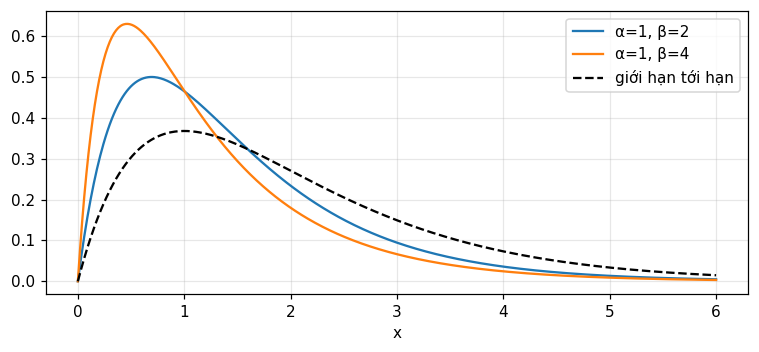

In [3]:
xs = np.linspace(-1, 6, 701)
plt.figure(figsize=(7, 3.3))
for al, be, c in ((1, 2, "tab:blue"), (1, 4, "tab:orange")):
    plt.plot(xs[xs >= 0], exp_formula(al, be, xs[xs >= 0]), color=c, label=f"α={al}, β={be}")
plt.plot(xs[xs >= 0], xs[xs >= 0]*np.exp(-xs[xs >= 0]), "k--", label=("giới hạn tới hạn"))
plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Tại $x=1$: $\Pi*e^{-x}H$ cho 0.3834, hai hàm mũ cắt cụt ($\alpha=1,\beta=2$) cho 0.4651, bộ cộng hưởng tới hạn tại $x=2$ cho 0.2707, hai đuôi ngược chiều cho 0.2453 ở $x=-1$ và 0.0902 ở $x=+1$ (bên phải rơi nhanh hơn). Làm mượt bằng trung bình 5 điểm giảm tổng biến thiên từ 48 xuống 11.6, và 3 trên 3 tính chất đại số đúng.

## 2. Lặp tích chập và các quy tắc diện tích, phương sai
🎯 **Phương pháp này trả lời câu hỏi gì?** Tích chập của các hàm diện tích 1 giữ diện tích, cộng phương sai, và lặp nhiều lần tiến về Gauss như thế nào? Ta lặp tích chập trên lưới mịn và so với công thức đóng (spline bậc hai) và với Gauss.

In [4]:
dxg = 0.001
cell = np.ones(1000)                                             # Π trên lưới: 1000 ô rộng 0.001
def repeated(n):
    z = cell.copy()
    for _ in range(n - 1):
        z = np.convolve(z, cell)*dxg
    return z
def value_at(z, x):                                              # nội suy tại x (tâm lưới ở giữa mảng)
    xs_ = (np.arange(len(z)) - (len(z) - 1)/2)*dxg
    return np.interp(x, xs_, z)
b3 = repeated(3)
spline = lambda x: 0.75 - x**2 if abs(x) <= 0.5 else (1.5 - abs(x))**2/2
assert abs(value_at(b3, 0) - 0.75) < 2e-3 and abs(value_at(b3, 1) - 0.125) < 2e-3
assert abs(value_at(b3, 0.3) - spline(0.3)) < 2e-3
report("b3_0", value_at(b3, 0), ".3f"); report("b3_1", value_at(b3, 1), ".3f")

# Diện tích và phương sai của e^{−x}H(x) * Π
xg = np.arange(0, 40, 0.002); fe = np.exp(-xg)
gp = np.ones(500)
conv = np.convolve(fe, gp)*0.002
xc = (np.arange(len(conv)) - 250)*0.002 + 0.001
area_c = trap(conv, xc); mean_c = trap(xc*conv, xc)/area_c
var_c = trap((xc - mean_c)**2*conv, xc)/area_c
assert abs(area_c - 1) < 5e-3 and abs(var_c - (1 + 1/12)) < 5e-3
report("area_conv", area_c, ".2f"); report("var_conv", var_c, ".4f")

# Tiến về Gauss: độ lệch tối đa với Gauss cùng phương sai
devs = {}
for n in (4, 8):
    z = repeated(n); xs_ = (np.arange(len(z)) - (len(z) - 1)/2)*dxg
    var = n/12.0; g = np.exp(-xs_**2/(2*var))/np.sqrt(2*np.pi*var)
    assert abs(trap(z, xs_) - 1) < 1e-3
    devs[n] = np.max(np.abs(z - g))
report("gauss_dev4", devs[4], ".4f"); report("gauss_dev8", devs[8], ".4f")

▸ b3_0 = 0.75
▸ b3_1 = 0.125
▸ area_conv = 1
▸ var_conv = 1.0833
▸ gauss_dev4 = 0.0243
▸ gauss_dev8 = 0.0092


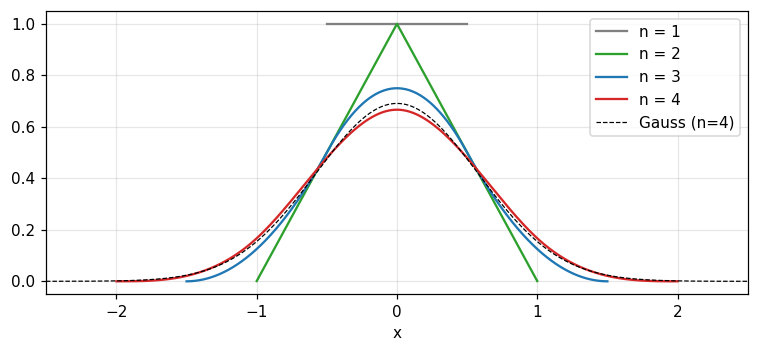

In [5]:
plt.figure(figsize=(7, 3.3))
for n, c in ((1, "gray"), (2, "tab:green"), (3, "tab:blue"), (4, "tab:red")):
    z = repeated(n); xs_ = (np.arange(len(z)) - (len(z) - 1)/2)*dxg
    plt.plot(xs_, z, color=c, label=f"n = {n}")
var = 4/12.0; xs_ = np.linspace(-2.5, 2.5, 1000)
plt.plot(xs_, np.exp(-xs_**2/(2*var))/np.sqrt(2*np.pi*var), "k--", lw=0.8, label=("Gauss (n=4)"))
plt.xlim(-2.5, 2.5); plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Lặp ba lần, $\Pi*\Pi*\Pi$ cho 0.75 tại 0 và 0.125 tại 1, khớp spline bậc hai $3/4-x^2$ và $1/8$. $e^{-x}H(x)*\Pi$ giữ diện tích 1 và có phương sai 1.0833 $=1+1/12$. Độ lệch tối đa so với Gauss cùng phương sai là 0.0243 khi $n=4$ và chỉ 0.0092 khi $n=8$: lặp tích chập tiến rất nhanh về Gauss.

## 3. Tích chập nối tiếp: nhân đa thức, chia dãy, bảng nghịch đảo, ma trận
🎯 **Phương pháp này trả lời câu hỏi gì?** Tích chập nối tiếp có trùng nhân đa thức, tổng chạy và sai phân có nghịch đảo nhau không, chia dãy có tìm lại thừa số, bảng 3.1 có đúng và ma trận Toeplitz có tái tạo tích chập không? Mỗi điều được kiểm bằng hai cách.

In [6]:
from scipy.linalg import toeplitz

# Nhân đa thức = tích chập nối tiếp
pa, pb = np.array([2, 2, 3, 3, 4]), np.array([1, 1, 2])
assert np.array_equal(np.polymul(pa, pb), np.convolve(pa, pb))
report("len74", len(np.convolve(np.arange(1, 8), np.arange(1, 5))), "d")

# Tổng chạy và sai phân
d0 = np.array([3, 1, 4, 1, 5, 9, 2, 6])
S = np.cumsum(d0)
diff_back = np.convolve(S, [1, -1])[:len(d0)]
assert np.array_equal(diff_back, d0) and np.array_equal(np.convolve(np.ones(len(d0)), d0)[:len(d0)], S)
report("run_last", S[-1], "d")

# Dãy nghịch đảo: {1,2,3,4,...}*{1,-2,1} và {1,-1}*{1,-1}
r1 = np.convolve(np.arange(1, 11), [1, -2, 1])[:10]
r2 = np.convolve([1, -1], [1, -1])
recip_ok = int(np.array_equal(r1, [1] + [0]*9)) + int(np.array_equal(r2, [1, -2, 1]))
assert recip_ok == 2
report("recip_ok", recip_ok, "d")

# Chia dãy: {1,1}*{g} = {1,3,3,1}. Cách A: đệ quy của Bracewell; cách B: chia đa thức
f_, h_ = [1, 1], [1, 3, 3, 1]
g_ = []
for k in range(len(h_) - len(f_) + 1):
    g_.append((h_[k] - sum(f_[j]*g_[k - j] for j in range(1, min(k, len(f_) - 1) + 1)))/f_[0])
q_, r_ = np.polydiv(h_, f_)
assert np.allclose(g_, q_) and np.allclose(r_, 0)
report("div_g", " ".join(str(int(z)) for z in g_), "s")

# Bảng 3.1: kiểm sáu cặp (chỉ N số hạng đầu, vì dãy nghịch đảo vô hạn)
Nn = 12; nnn = np.arange(Nn); a_t = 0.5
pairs = [([1, 1], (-1.0)**nnn), ([1, -1], np.ones(Nn)), ([1, 0, 1], np.array([1, 0, -1, 0]*3, float)),
         ([1, 2, 1], (-1.0)**nnn*(nnn + 1)), ([1, -a_t], a_t**nnn), (np.convolve([1, -a_t], [1, -a_t]), (nnn + 1)*a_t**nnn)]
tab_ok = sum(bool(np.allclose(np.convolve(f_t, g_t)[:Nn], [1] + [0]*(Nn - 1))) for f_t, g_t in pairs)
assert tab_ok == 6
report("tab_ok", tab_ok, "d")

# Dạng ma trận: ma trận Toeplitz tam giác dưới nhân vector
ff, gg = np.array([2, 2, 3, 3, 4.0]), np.array([1, 1, 2.0])
L_ = len(ff) + len(gg) - 1
T = toeplitz(np.r_[ff, np.zeros(L_ - len(ff))], np.r_[ff[0], np.zeros(L_ - 1)])
toep = np.allclose(T @ np.r_[gg, np.zeros(L_ - len(gg))], np.convolve(ff, gg))
assert toep
report("toep_ok", "yes" if toep else "no", "s")

▸ len74 = 10
▸ run_last = 31
▸ recip_ok = 2
▸ div_g = 1 2 1
▸ tab_ok = 6
▸ toep_ok = yes


#### 📤 Đầu ra thật
Nhân đa thức và <code>convolve</code> trùng nhau; dãy 7 chập dãy 4 cho 10 số hạng. Tổng chạy của $\{3,1,4,1,5,9,2,6\}$ kết thúc ở 31 và lấy sai phân trả lại dãy gốc. 2 trên 2 cặp nghịch đảo đúng. Chia dãy cho $\{g\}$ = (1 2 1) bằng cả đệ quy và chia đa thức. Bảng 3.1: 6 trên 6 cặp đúng. Ma trận Toeplitz tái tạo tích chập: yes.

## 4. Tích chập bằng máy tính
🎯 **Phương pháp này trả lời câu hỏi gì?** Đoạn mã trực tiếp của Bracewell có đúng không, các chế độ độ dài là gì, khi nào FFT cuộn vòng, và trung bình 7 ngày làm gì với chu kỳ tuần? Ta so mã tay với <code>convolve</code>, đếm phép nhân, và so tích chập vòng với FFT.

In [7]:
import math

def direct_conv(f, g):
    """Dịch từ đoạn mã của Bracewell (tr. 40)"""
    lf, lg = len(f), len(g); lh = lf + lg - 1
    h = np.zeros(lh)
    for i in range(lh):
        for j in range(max(i - lg + 1, 0), min(lf - 1, i) + 1):
            h[i] += f[j]*g[i - j]
    return h

rgc = np.random.default_rng(3)
cd = 0.0
for la, lb in ((200, 37), (5, 5)):
    fa, gb = rgc.standard_normal(la), rgc.standard_normal(lb)
    cd = max(cd, np.max(np.abs(direct_conv(fa, gb) - np.convolve(fa, gb))))
assert cd < 1e-12
report("code_diff", cd, ".1e")

x10, x4 = np.arange(10.0), np.arange(4.0)
report("len_full", len(np.convolve(x10, x4, "full")), "d"); report("len_same", len(np.convolve(x10, x4, "same")), "d")
report("len_valid", len(np.convolve(x10, x4, "valid")), "d")

# Đếm phép nhân (ước lượng bậc độ lớn)
def next_pow2(n): return 1 << (n - 1).bit_length()
lf = 10**5
for lg, tag in ((32, "short"), (2000, "long")):
    N_ = next_pow2(lf + lg - 1)
    report(f"ops_direct_{tag}", lf*lg, ",.0f")
    report("ops_fft" if tag == "short" else "ops_fft2", 3*N_*math.log2(N_), ",.0f")

# Bẫy cuộn vòng
fw, gw = rgc.standard_normal(8), rgc.standard_normal(3)
lin = np.convolve(fw, gw)
circ = np.fft.ifft(np.fft.fft(fw, 8)*np.fft.fft(gw, 8)).real
wrap = np.max(np.abs(circ - lin[:8]))                            # so với 8 số hạng đầu của tích chập thẳng
padded = np.fft.ifft(np.fft.fft(fw, 16)*np.fft.fft(gw, 16)).real[:10]
pad = np.max(np.abs(padded - lin))
assert wrap > 0.1 and pad < 1e-12
report("wrap_err", wrap, ".2f"); report("pad_err", pad, ".1e")

# Trung bình 7 ngày trên chuỗi 364 ngày (đóng vòng): tích chập vòng so với FFT
dd = np.arange(364)
temp = 20 + 3*np.sin(2*np.pi*dd/364) + 2*np.sin(2*np.pi*dd/7)
smooth_c = np.convolve(np.pad(temp, (3, 3), mode="wrap"), np.ones(7)/7, "valid")
hker = np.zeros(364); hker[[364 - 3, 364 - 2, 364 - 1, 0, 1, 2, 3]] = 1/7
smooth_f = np.fft.ifft(np.fft.fft(temp)*np.fft.fft(hker)).real
assert np.allclose(smooth_c, smooth_f)
A_b, A_a = amplitude_spectrum(temp), amplitude_spectrum(smooth_c)
season_th = 3*abs(np.sin(7*np.pi/364)/(7*np.sin(np.pi/364)))
assert abs(A_a[1] - season_th) < 1e-9 and A_a[52] < 1e-9
report("wk_before", A_b[52], ".2f"); report("wk_after", A_a[52], ".2f")
report("season_after", A_a[1], ".4f"); report("season_th", season_th, ".4f")

▸ code_diff = 5.3e-15
▸ len_full = 13
▸ len_same = 10
▸ len_valid = 7
▸ ops_direct_short = 3,200,000
▸ ops_fft = 6,684,672
▸ ops_direct_long = 200,000,000
▸ ops_fft2 = 6,684,672
▸ wrap_err = 1.09
▸ pad_err = 4.4e-16
▸ wk_before = 2
▸ wk_after = 0
▸ season_after = 2.9982
▸ season_th = 2.9982


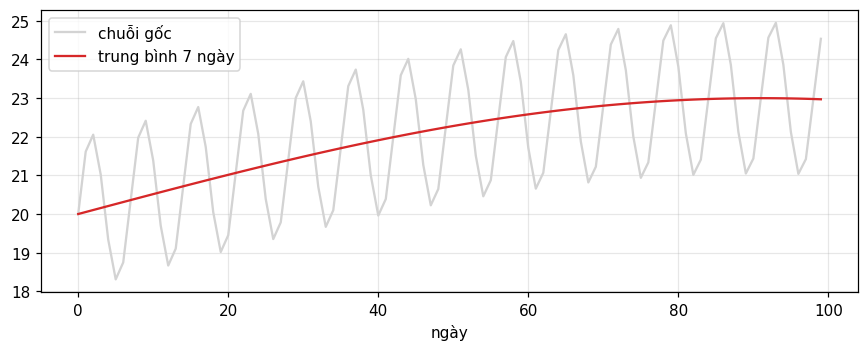

In [8]:
plt.figure(figsize=(8, 3.3))
plt.plot(dd[:100], temp[:100], color="lightgray", label=("chuỗi gốc"))
plt.plot(dd[:100], smooth_c[:100], "tab:red", label=("trung bình 7 ngày"))
plt.xlabel(("ngày")); plt.legend(); plt.tight_layout(); plt.show()

#### 📤 Đầu ra thật
Mã tay của Bracewell trùng <code>convolve</code> (lệch 5.3e-15). Với hai dãy 10 và 4: 13, 10, 7 số hạng ở ba chế độ full, same, valid. Số phép nhân: 3,200,000 so với cỡ 6,684,672 của FFT cho bộ lọc ngắn, và 200,000,000 so với 6,684,672 cho bộ lọc dài. FFT không đệm số 0 lệch 1.09 (cuộn vòng), đệm rồi lệch chỉ 4.4e-16. Trung bình 7 ngày đưa biên độ tuần từ 2 xuống 0 và giữ mùa ở 2.9982 (lý thuyết 2.9982).

## 5. Tự tương quan, tương quan chéo, bậc ba và phổ năng lượng
🎯 **Phương pháp này trả lời câu hỏi gì?** Các công thức tự tương quan trong chương có đúng không, pha có thật sự bị mất, tương quan bậc ba có phân biệt chiều thời gian, và phổ năng lượng có tương đương tự tương quan? Ta so tích phân số với công thức, và tính trực tiếp với tính qua FFT.

In [9]:
def autocorr_tri(x):                                             # f = 1 − u trên (0, 1): tích phân số
    x = abs(x)
    return integrate.quad(lambda u: (1 - u)*(1 - u - x), 0, 1 - x)[0] if x < 1 else 0.0
g_formula = lambda x: 1 - 1.5*abs(x) + 0.5*abs(x)**3
for xv in (0.0, 0.25, 0.5, 0.9):
    assert abs(autocorr_tri(xv)/autocorr_tri(0) - g_formula(xv)) < 1e-12
area_num = integrate.quad(autocorr_tri, -1, 1, points=[0])[0]
assert abs(area_num - 0.25) < 1e-9
report("g_025", g_formula(0.25), ".4f"); report("g_05", g_formula(0.5), ".4f"); report("area_ac", area_num, ".4f")

num = integrate.quad(lambda u: np.exp(-u)*np.exp(-(u + 1.0)), 0, np.inf)[0]     # e^{−x}H(x): γ(1)
assert abs(num/0.5 - np.exp(-1)) < 1e-12
report("g_exp", num/0.5, ".4f")

# Cực đại tại gốc, trên dãy xác định
sig = np.sin(np.arange(200)**1.3) + 0.3*np.cos(np.arange(200)/3)
ac = np.correlate(sig, sig, "full"); mid = len(sig) - 1
ratio = np.max(np.abs(np.delete(ac, mid)))/ac[mid]
assert ratio < 1 and abs(ac[mid] - np.sum(sig**2)) < 1e-9
report("ac_ratio", ratio, ".4f")

# Ba sóng hình sin: C(τ) không phụ thuộc pha
tt = np.arange(1000)/1000
def three(ph):
    return 2*np.sin(2*np.pi*3*tt + ph[0]) + 1*np.sin(2*np.pi*5*tt + ph[1]) + 0.5*np.sin(2*np.pi*8*tt + ph[2])
def C_circ(v, k):                                                # tự tương quan chuẩn hóa (chu kỳ 1 s)
    return np.mean(v*np.roll(v, -k))/np.mean(v*v)
C_th = lambda tau: (4*np.cos(2*np.pi*3*tau) + np.cos(2*np.pi*5*tau) + 0.25*np.cos(2*np.pi*8*tau))/5.25
ph1, ph2 = (0.3, 1.1, 2.0), (2.5, 0.2, 4.0)
diffs = [abs(C_circ(three(p), k) - C_th(k/1000)) for p in (ph1, ph2) for k in (0, 50, 137, 400)]
assert max(diffs) < 1e-9
pd_ = max(abs(C_circ(three(ph1), k) - C_circ(three(ph2), k)) for k in range(0, 1000, 50))
report("c_tau", C_th(0.05), ".4f"); report("phase_diff", pd_, ".1e")

▸ g_025 = 0.6328
▸ g_05 = 0.3125
▸ area_ac = 0.25
▸ g_exp = 0.3679
▸ ac_ratio = 0.2821
▸ c_tau = 0.4093
▸ phase_diff = 2.2e-16


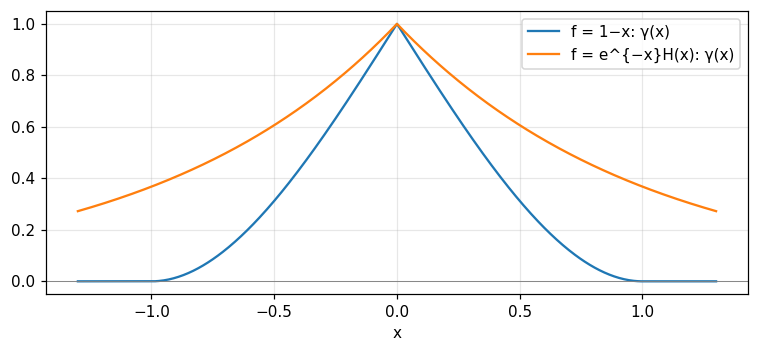

In [10]:
xs = np.linspace(-1.3, 1.3, 521)
plt.figure(figsize=(7, 3.3))
plt.plot(xs, [g_formula(x) if abs(x) < 1 else 0 for x in xs], label=("f = 1−x: γ(x)"))
plt.plot(xs, np.exp(-np.abs(xs)), label=("f = e^{−x}H(x): γ(x)"))
plt.axhline(0, color="gray", lw=0.6); plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
# Tương quan bậc ba U(x1, x2) = Σ f(x) f(x+x1) f(x+x2). Cách A: vòng lặp; cách B: einsum
def triple_loops(f, m):
    n = len(f); P = np.zeros(n + 2*m); P[m:m + n] = f
    U = np.zeros((2*m + 1, 2*m + 1))
    for i, x1 in enumerate(range(-m, m + 1)):
        for j, x2 in enumerate(range(-m, m + 1)):
            U[i, j] = sum(P[m + x]*P[m + x + x1]*P[m + x + x2] for x in range(-m, n + m) if 0 <= m + x < n + 2*m and 0 <= m + x + x1 < n + 2*m and 0 <= m + x + x2 < n + 2*m)
    return U
def triple_einsum(f, m):
    n = len(f); P = np.zeros(n + 6*m); P[3*m:3*m + n] = f
    S = np.stack([np.roll(P, -s) for s in range(-m, m + 1)])
    return np.einsum("x,ix,jx->ij", P, S, S)
f123, f321 = np.array([1, 2, 3.0]), np.array([3, 2, 1.0])
U123, U321 = triple_loops(f123, 2), triple_loops(f321, 2)
assert np.allclose(U123, triple_einsum(f123, 2)) and np.allclose(U321, U123[::-1, ::-1])
assert U123[2, 2] == 36 and U123.sum() == 216 and not np.allclose(U123, U321)
assert np.allclose(np.correlate(f123, f123, "full"), np.correlate(f321, f321, "full"))
report("ac_same", "yes", "s"); report("tc_diff", "yes", "s")
report("tc_center", U123[2, 2], ".0f"); report("tc_sum", U123.sum(), ".0f")
for r in range(5):
    report(f"tc_r{r}", " ".join(f"{z:.0f}" for z in U123[r]), "s")

# Tương quan chéo: g⋆h(x) = h⋆g(−x), và không giao hoán
def xcorr(g, h):
    n = len(g); P = lambda z, k: z[k] if 0 <= k < n else 0.0
    return {x: sum(P(g, u - x)*P(h, u) for u in range(-n, 2*n)) for x in range(-(n - 1), n)}
ga, hb = np.array([1.0, 2, 4, 3]), np.array([2.0, 0, 1, 5])
c_gh, c_hg = xcorr(ga, hb), xcorr(hb, ga)
xc_ok = all(abs(c_gh[x] - c_hg[-x]) < 1e-12 for x in c_gh); xc_ne = any(abs(c_gh[x] - c_hg[x]) > 1e-9 for x in c_gh)
assert xc_ok and xc_ne
report("xc_ok", "yes", "s"); report("xc_ne", "yes", "s")

# Phổ năng lượng: IDFT(|X|²) = tự tương quan vòng; hai tín hiệu khác pha cùng phổ
v = np.sin(np.arange(64)**1.2) + 0.5
ac_direct = np.array([np.sum(v*np.roll(v, -k)) for k in range(64)])
ac_fft = np.fft.ifft(np.abs(np.fft.fft(v))**2).real
assert np.allclose(ac_direct, ac_fft)
report("wk_diff", np.max(np.abs(ac_direct - ac_fft)), ".1e")
xa, xb = three(ph1), three(ph2)
assert np.allclose(np.abs(np.fft.fft(xa)), np.abs(np.fft.fft(xb)))
report("pha_diff", np.max(np.abs(np.abs(np.fft.fft(xa))**2 - np.abs(np.fft.fft(xb))**2)), ".1e")

# Phổ năng lượng tích lũy: vạch 50 Hz cộng nhiễu
rgn = np.random.default_rng(11)
tn = np.arange(1000)/1000
yn = 3*np.sin(2*np.pi*50*tn) + rgn.normal(0, 0.5, 1000)
En = np.abs(np.fft.rfft(yn))**2; cum = np.cumsum(En)/np.sum(En)
assert abs(np.sum(En[1:500])*2/1000/1000 - np.mean(yn**2)) < 5e-2
report("cum_before", cum[49], ".3f"); report("cum_after", cum[51], ".3f"); report("cum_jump", cum[51] - cum[49], ".3f")

# Dãy xung {1100101}
pj = np.array([1, 1, 0, 0, 1, 0, 1.0])
lin_ac = np.correlate(pj, pj, "full")
circ_ac = np.array([np.sum(pj*np.roll(pj, -k)) for k in range(7)])
assert lin_ac[6] == 4 and np.all(circ_ac[1:] == 2)
report("ac_peak", lin_ac[6], ".0f"); report("ac_side", np.max(np.delete(lin_ac, 6)), ".0f"); report("ac_circ", circ_ac[1], ".0f")

▸ ac_same = yes
▸ tc_diff = yes
▸ tc_center = 36
▸ tc_sum = 216
▸ tc_r0 = 3 6 9 0 0
▸ tc_r1 = 6 14 22 6 0
▸ tc_r2 = 9 22 36 14 3
▸ tc_r3 = 0 6 14 22 6
▸ tc_r4 = 0 0 3 6 9
▸ xc_ok = yes
▸ xc_ne = yes
▸ wk_diff = 7.1e-15
▸ pha_diff = 2.3e-10
▸ cum_before = 0.005
▸ cum_after = 0.951
▸ cum_jump = 0.946
▸ ac_peak = 4
▸ ac_side = 1
▸ ac_circ = 2


#### 📤 Đầu ra thật
Với $f=1-x$: $\gamma(0.25)$ = 0.6328, $\gamma(0.5)$ = 0.3125, diện tích tử số 0.25; với $e^{-x}H(x)$: $\gamma(1)$ = 0.3679. Tự tương quan không vượt đỉnh (tỉ số thùy phụ 0.2821). Với ba sóng, $C(0.05)$ = 0.4093 và không phụ thuộc pha (lệch 2.2e-16). Tương quan bậc ba của $\{1,2,3\}$ có tâm 36, tổng 216, và khác của $\{3,2,1\}$ dù tự tương quan hai dãy giống nhau (yes). Tương quan chéo thỏa $g\star h(x)=h\star g(-x)$ (yes) nhưng không giao hoán (yes). Biến đổi ngược $|X|^2$ trùng tự tương quan vòng (lệch 7.1e-15), và hai tín hiệu khác pha có cùng phổ năng lượng (lệch 2.3e-10). Phổ tích lũy nhảy 0.946 tại vạch 50 Hz. Dãy $\{1100101\}$ có đỉnh 4, thùy phụ 1 và tự tương quan vòng 2.